# Importations

In [9]:
# Numerical and scientific python programming
import numpy as np

import matplotlib.pyplot as plt

# Local importations
from moments.bloch import compute_pauli_basis, compute_tensor_basis, compute_subset_index_map
from moments.optimization import optimize_moment_preserving_entanglement

# Space definition and discretization

In [6]:
N = 2
d = 2 ** N

pauli_basis = compute_pauli_basis()
local_bases = [pauli_basis.copy()] * N
local_basis_sizes = [len(basis) for basis in local_bases]

tensor_basis = compute_tensor_basis(local_bases)
subset_index_map = compute_subset_index_map(local_basis_sizes)

## Analytical conditions

In general, the 3D region explored consits of a subset of $\mathbb R^3$ that satisfy certain constraints.
In particular, those are

- $x, y, z \ge 0$,
- $z \ge x + y - 1$,
- $z^2 \le 3 + x^2 + y^2 - 4xy - 4|x-y|$,
- $x = y$.

Therefore, is the intersection of a region in the first quadrant and the plane $x=y$. Since $x=y$, the inequalities become:

- $x, z \ge 0$,
- $z \ge 2x - 1$,
- $z \le \sqrt{3 - 2 x^2}$.

In [7]:
D = 20
Dx, Dz = D + 1, int(np.sqrt(3) * D) + 1

x = np.linspace(0, 1, Dx)
z = np.linspace(0, np.sqrt(3), Dz)

X, Z = np.meshgrid(x, z, indexing='ij')
Y = X

mask1 = Z >= 2*X - 1
mask2 = Z**2 <= 3 - 2*X**2

mask = mask1 & mask2

points = np.column_stack((X[mask], X[mask], Z[mask]))
print(f"Number of points: {points.shape[0]}")

Number of points: 520


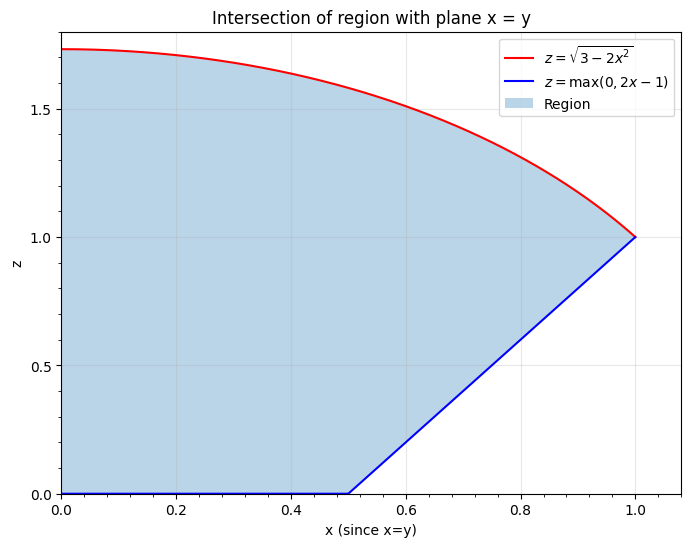

In [29]:
# Create a fine grid for plotting
x_plot = np.linspace(0, 1, 500)
z_upper = np.sqrt(3 - 2*x_plot**2)

# Lower boundary: max(0, 2x-1)
z_lower = np.maximum(0, 2*x_plot - 1)

# Plot
fig, ax = plt.subplots(figsize = (8, 6))

ax.plot(x_plot, z_upper, 'r-', label=r'$z = \sqrt{3 - 2x^2}$')
ax.plot(x_plot, z_lower, 'b-', label=r'$z = \max(0, 2x-1)$')
ax.fill_between(x_plot, z_lower, z_upper, alpha=0.3, label='Region')

ax.set(xlabel = 'x (since x=y)',  ylabel = 'z', title = 'Intersection of region with plane x = y',
       xlim = (0, 1.08), ylim = (0, 1.8), xticks = np.arange(0, 1.11, 0.2), yticks = np.arange(0, 1.81, 0.5))
ax.set_xticks(np.arange(0, 1.11, 0.04), minor = True)
ax.set_yticks(np.arange(0, 1.81, 0.1), minor = True)
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

# Optimization